# BFW and SFW Combined Technique

In [2]:
import numpy as np
import pandas as pd
from time import process_time
import matplotlib.pyplot as plt

import warnings
warnings.simplefilter('ignore')

# Problem

$$ f(Ax) = \frac{1}{2m} \|Ax - b\|_{2}^2  = \frac{1}{m}\sum_{i=1}^{m}f_i(\langle A_{i},x \rangle) $$

$$ A \in \mathbb{R}^{m \times n}, x \in \mathbb{R}^{n}, b \in \mathbb{R}^{m} $$



$$ min\text{ } \frac{1}{2m} ||Ax - b||_{2}^2,\text{ } x \in C $$
$$ C = ||x||_1 <= 100 $$ 

In [15]:
m = 4
n = 1
min_value = -10
max_value = 10

A = np.random.randint(min_value, max_value + 1, size=(m, n))
x_opt = np.random.randint(min_value, max_value + 1, size = (n,))
x_opt = 90 * x_opt / np.linalg.norm(x_opt, ord=1)
print(x_opt)
b = A @ x_opt
print(A)
print(b)

[-90.]
[[ 8]
 [-6]
 [-5]
 [-7]]
[-720.  540.  450.  630.]


# Stochastic Gradient

$$ f_i: \mathbb{R} \rightarrow \mathbb{R}, \quad u \mapsto \frac{1}{2} (u - b_i)^{2} $$

$$ f_{i}'( \langle A_{i}, x \rangle) = ( \langle A_{i},x \rangle - b_i) $$

$$ \alpha_{0} \in \mathbb{R}^{m}, r_0 = A^T \alpha_0 $$

# Boosted FW

NOTE: Here, $f(x)$ function passes $f(Ax)$ by default for its calculations

In [4]:
def lmo(v):
    max_index = np.argmax(np.absolute(v))
    sign = np.sign(v[max_index])
    chosen = np.zeros_like(v)
    #note that we minimize by setting another - sign, as we want a vector in the OPPOSITE direction of the largest value.
    #that way, it gives the largest opposite direction to go, so the inner product is negative
    chosen[max_index] = -100*sign
    #implement convex combo
    return chosen

def analytic_grad_f(x):
    return (1/m)*np.dot(A.T,(np.dot(A,x) - b))

def segment_search(f, x, y, tol=1e-6, stepsize=True):
    
    '''
    Minimizes f over [x, y], i.e., f(x+gamma*(y-x)) as a function of scalar gamma in [0,1]
    '''
    
    # restrict segment of search to [x, y]
    d = (y-x).copy()
    left, right = x.copy(), y.copy()
    
    # if the minimum is at an endpoint

    if np.dot(d, analytic_grad_f(x))*np.dot(d, analytic_grad_f(y)) >= 0:
        if f(y) <= f(x):
            return y, 1
        else:
            return x, 0

    
    # apply golden-section method to segment
    gold = (1+np.sqrt(5))/2
    improv = np.inf
    while improv > tol:
        old_left, old_right = left, right
        new = left+(right-left)/(1+gold)
        probe = new+(right-new)/2
        if f(probe) <= f(new):
            left, right = new, right
        else:
            left, right = left, probe
        improv = np.linalg.norm(f(right)-f(old_right))+np.linalg.norm(f(left)-f(old_left))
    x_min = (left+right)/2
    
    # compute step size gamma
    gamma = 0
    if stepsize == True:
        for i in range(len(d)):
            if d[i] != 0:
                gamma = (x_min[i]-x[i])/d[i]
                break
                
    return x_min, gamma

def f(x,A=A):
    Ax = A @ x
    Ax_minus_b = Ax - b
    norm_squared = np.linalg.norm(Ax_minus_b, ord=2)**2
    result = norm_squared / (2 * m)
    return result

In [5]:
def align(d, hat_d):
    #if <1e-15, its nan
    if np.linalg.norm(hat_d) < 1e-15:
        return -1
    else:
        return np.dot(d, hat_d)/(np.linalg.norm(d)*np.linalg.norm(hat_d))
        

def nnmp(x, grad_f_x, align_tol, K):
    
    '''
    Minimizes ||-grad_f_x-d||_2^2/2 s.t. d in cone(V-x)
    '''
    
    d, Lbd, flag = np.zeros(len(x)), 0, True
    
    G = grad_f_x+d
    align_d = align(-grad_f_x, d)
    for k in range(K):
        
        u = lmo(G)-x
        #print('u','x',u,x)
        d_norm = np.linalg.norm(d)
        if d_norm > 0 and np.dot(G, -d/d_norm) < np.dot(G, u):
            u = -d/d_norm
            flag = False
        lbd = -np.dot(G, u)/np.linalg.norm(u)**2
        dd = d+lbd*u
        align_dd = align(-grad_f_x, dd)
        align_improv = align_dd-align_d
        
        if align_improv > align_tol:
            d = dd
            Lbd = Lbd+lbd if flag == True else Lbd*(1-lbd/d_norm)
            G = grad_f_x+d
            align_d = align_dd
            flag = True
        else:
            break
        
    return d/Lbd, k, align_d

def boostfw(f, x, f_tol=1e-6, time_tol=np.inf, align_tol=1e-3, K=500):
    alpha = np.random.rand(A.shape[0])
    grad_f_x = (1./A.shape[0]) * (A.T @ alpha)
    values, times, oracles, gaps = [f(x)], [0], [0], [np.dot(grad_f_x, x-lmo(grad_f_x))]
    x = np.zeros_like(x)

    f_improv = np.inf

    start = process_time()
    x = lmo(grad_f_x)
    end = process_time()
    values.append(f(x))
    times.append(end-start)
    oracles.append(1)

    iteration_no = 1

    while f_improv > f_tol and np.sum(times) < time_tol:
                
        f_old = f(x)
        start = process_time()
        
        #looped recurrence
        num_samples = 1
        # Sample some rows of A
        sampled_indices = np.random.choice(A.shape[0], size=num_samples, replace=False)
        # Update the components of alpha according to what's been sampled
        new_alpha_components = (1./A.shape[0]) * (np.dot(A[sampled_indices], x) - b[sampled_indices])
        # Compute stochastic gradient estimator r
        grad_f_x = grad_f_x + A[sampled_indices].T @ (new_alpha_components - alpha[sampled_indices])
        # Update the alpha components
        alpha[sampled_indices] = new_alpha_components   
        
        t1 = process_time()
        gaps.append(np.dot(grad_f_x, x-lmo(grad_f_x)))
        t2 = process_time()
        
        """
        below step repeats the alignment loop to get back 
        1) normalised gt
        2) no of loops taken (k val) called num_oracles
        3) align_g which is how much the vectors g and -grad_f_x lie on a line
        """
        g, num_oracles, align_g = nnmp(x, grad_f_x, align_tol, K)
        
        #removing other 2 cases
        x, gamma = segment_search(f, x, x+g)
        x = x+gamma*g
        
        end = process_time()
        values.append(f(x))
        times.append(end-start+t1-t2)
        oracles.append(num_oracles)
        f_improv = f_old-f(x)
        iteration_no+=1
        
    return x, values, times, oracles, gaps, iteration_no

In [6]:
def vanilla_fw(f, x, f_tol=1e-6, time_tol=np.inf, no_iters=500):
    k=0

    alpha = np.random.rand(A.shape[0])
    grad_f_x = (1./A.shape[0]) * (A.T @ alpha)
    values, times, oracles, gaps = [f(x)], [0], [0], [np.dot(grad_f_x, x-lmo(grad_f_x))]
    f_improv = np.inf

    x = lmo(grad_f_x)
    values.append(f(x))

    while f_improv > f_tol and k<no_iters:
        f_old = f(x)
        #looped recurrence
        num_samples = 1
        # Sample some rows of A
        sampled_indices = np.random.choice(A.shape[0], size=num_samples, replace=False)
        # Update the components of alpha according to what's been sampled
        new_alpha_components = (1./A.shape[0]) * (np.dot(A[sampled_indices], x) - b[sampled_indices])
        # Compute stochastic gradient estimator r
        grad_f_x = grad_f_x + A[sampled_indices].T @ (new_alpha_components - alpha[sampled_indices])
        # Update the alpha components
        alpha[sampled_indices] = new_alpha_components 

        sk = lmo(grad_f_x)
        x, gamma = segment_search(f,x,x+sk)
        x = x + gamma*sk

        values.append(f(x))

        oracles.append(1)
        f_improv = f_old-f(x)
        k+=1
    return x, values, times, oracles, gaps, k

# Running the Program

In [7]:
f_tol, time_tol, align_tol = 1e-6, np.inf, 1e-3
x0 = np.random.randint(min_value,max_value,size =(n,))

In [8]:
res = {}
res['boostfw'] = boostfw(f,x0,f_tol=f_tol, time_tol=time_tol, align_tol=align_tol)
res['vanillafw'] = vanilla_fw(f,x0,f_tol=f_tol, time_tol=time_tol)

Final non-zero values of x: (array([0]),)
No of Iterations: 7
Final x: [97.43673976]
No of Iterations: 7


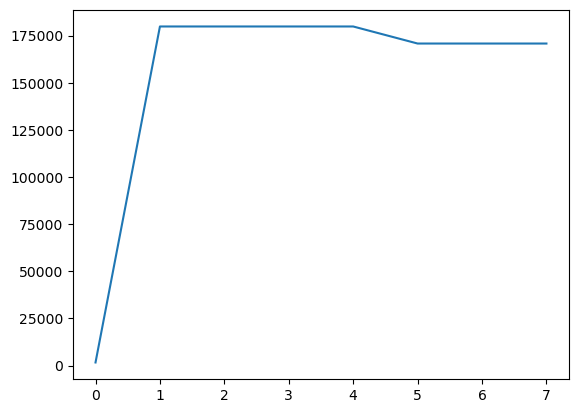

In [9]:
#x, values, times, oracles, gaps
x_final_bsfw = res['boostfw'][0]
no_iters = res['boostfw'][-1]
plt.plot(res['boostfw'][1]);
print(f'Final non-zero values of x: {np.nonzero(x_final_bsfw)}\nNo of Iterations: {no_iters}')
print(f'Final x: {x_final_bsfw}\nNo of Iterations: {no_iters}')

Final x: [98.71823691]
No of Iterations: 7
Final non-zero values of x: (array([0]),)
No of Iterations: 7


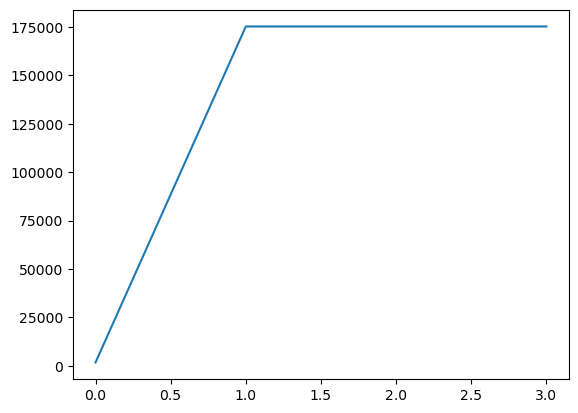

In [10]:
x_final_van = res['vanillafw'][0]
no_iters = res['boostfw'][-1]
plt.plot(res['vanillafw'][1]);
print(f'Final x: {x_final_van}\nNo of Iterations: {no_iters}')
print(f'Final non-zero values of x: {np.nonzero(x_final_van)}\nNo of Iterations: {no_iters}')

In [11]:
f(x_final_bsfw) < f(x_final_van)

True

In [12]:
f(x_final_bsfw)

170758.10986887803